In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

In [2]:
df = pd.read_excel(r"C:\Users\Chaithanya\Downloads\Task3_Sales_Dataset.xlsx")

In [3]:
df.head()

,Order ID,Order Date,Customer ID,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,ORD0001,2026-04-12,CUST321,Kiran,Home Office,North,Technology,General,Product 35,827.15,2,0.23,104.28
1,ORD0002,2025-07-19,CUST180,Ravi,Corporate,East,Technology,General,Product 49,1921.60,2,0.15,264.21
2,ORD0003,2025-07-28,CUST526,Arjun,Home Office,North,Office Supplies,General,Product 27,2382.08,2,0.20,272.84
3,ORD0004,2025-08-20,CUST241,Vikram,Home Office,South,Office Supplies,General,Product 3,268.05,10,0.04,22.40
4,ORD0005,2025-04-25,CUST872,Sneha,Corporate,North,Furniture,General,Product 15,4246.80,3,0.10,666.17


In [4]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Customer ID', 'Customer Name', 'Segment',
       'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

print(monthly_sales)

Order Date
1     135565.18
2     118747.15
3     142830.63
4     145347.07
5     139194.14
6      88353.64
7      57344.89
8      73630.87
9      43596.69
10    106847.96
11     75810.57
12     79773.31
Name: Sales, dtype: float64


In [6]:
business_target = 100000

In [7]:
t_statistic, p_value = ttest_1samp(monthly_sales, business_target)

print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

T-Statistic: 0.057162529592228215
P-Value: 0.9554408697739273


In [8]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("Average monthly sales are significantly different from the business target.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("Average monthly sales are NOT significantly different from the business target.")

Fail to Reject the Null Hypothesis
Average monthly sales are NOT significantly different from the business target.


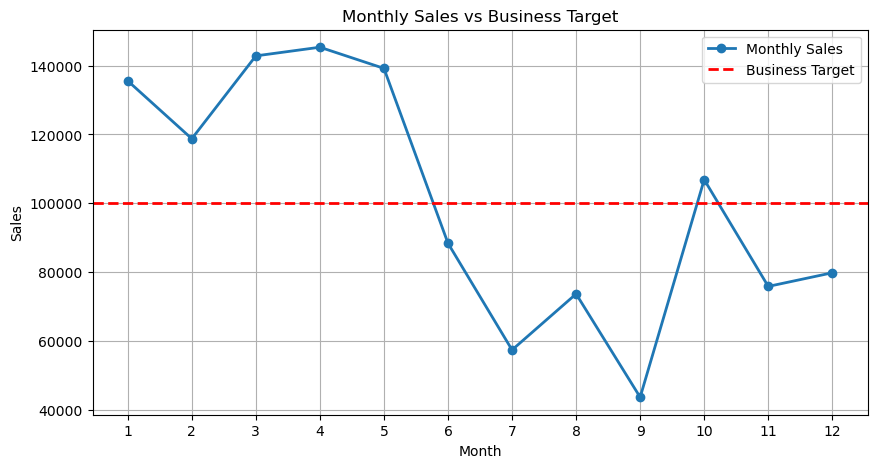

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=2,
         label='Monthly Sales')

plt.axhline(y=100000,
            color='red',
            linestyle='--',
            linewidth=2,
            label='Business Target')

plt.title("Monthly Sales vs Business Target")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1,13))
plt.grid(True)
plt.legend()

plt.show()